# 03 - Modelo de regresion lineal

Este notebook carga el dataset limpio, codifica las variables categoricas, ajusta un modelo
`LinearRegression` de scikit-learn y valida graficamente los supuestos del modelo (sin tests
estadisticos).


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats

TARGET = 'produccion_toneladas'
FEATURES = ['año', 'id_municipio', 'subregion']
SEED = 42

# Localizar la raiz del proyecto
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'frutales_limpias.csv')
print('Forma:', df.shape)
df.head()


Forma: (943, 4)


,produccion_toneladas,año,id_municipio,subregion
0,14088.0,2022,76233,Sur
1,6578.0,2022,76100,Norte
2,26000.0,2022,76243,Norte
3,186.0,2022,76001,Sur
4,2124.4,2022,76275,Sur


In [18]:
# Codificar la variable categorica con dummies. drop_first=True evita la multicolinealidad:
#  - subregion (4 categorias) -> 3 columnas dummy.
# Las numericas (año, id_municipio) quedan sin cambios.
X = pd.get_dummies(df[FEATURES], drop_first=True)
y = df[TARGET]

print('Columnas tras get_dummies:', X.columns.tolist())
print('Objetivo:', y.name)


Columnas tras get_dummies: ['año', 'id_municipio', 'subregion_Norte', 'subregion_Pacifico', 'subregion_Sur']
Objetivo: produccion_toneladas


In [19]:
# Division en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (754, 5) | Test: (189, 5)


In [20]:
# Ajuste del modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Intercepto (b0):', round(modelo.intercept_, 4))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
coeficientes


Intercepto (b0): -509200.3444


,Variable,Coeficiente
0,año,240.593583
1,id_municipio,0.452513
2,subregion_Norte,-4302.004204
3,subregion_Pacifico,-7881.796673
4,subregion_Sur,-7111.302664


El **intercepto** es el valor predicho cuando todos los predictores valen 0 (es decir, para la
categoria base de cada dummy). Cada **coeficiente** indica cuanto cambia la produccion predicha
al aumentar en 1 unidad ese predictor, manteniendo el resto constante.


In [21]:
# Predicciones y residuos sobre el conjunto de prueba
y_pred = modelo.predict(X_test)
residuos = y_test - y_pred


## Validacion de supuestos (grafica)


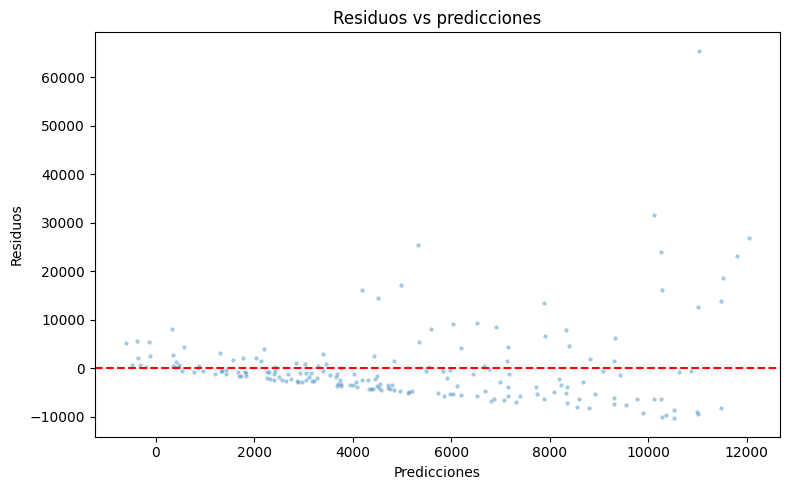

In [22]:
# Linealidad y homocedasticidad: residuos vs predicciones
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.savefig(FIGURES / 'residuos_vs_predicciones.png', dpi=150)
plt.show()


**Linealidad**: los residuos deben repartirse de forma aleatoria alrededor de la linea y=0, sin
patrones curvos. **Homocedasticidad**: la dispersion vertical de los puntos debe ser constante a
lo largo del eje X (sin forma de embudo).

Nota: como los predictores son debiles, las predicciones se concentran en un rango pequeno y los
residuos extremos dominan el grafico; conviene fijarse en la nube central de puntos.


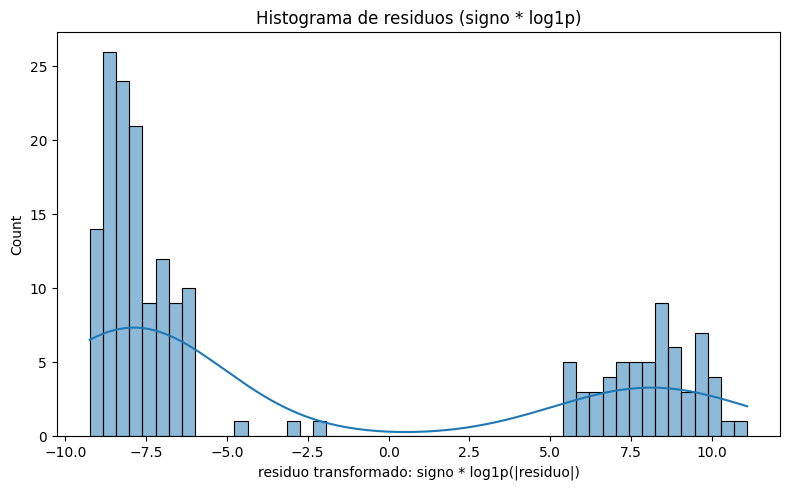

In [23]:
# Histograma de residuos (normalidad)
# Los residuos tienen extremos grandes (la produccion esta sesgada);
# signo * log1p(|residuo|) comprime los extremos sin perder el signo.
residuos_t = np.sign(residuos) * np.log1p(np.abs(residuos))

plt.figure(figsize=(8, 5))
sns.histplot(residuos_t, bins=50, kde=True)
plt.title('Histograma de residuos (signo * log1p)')
plt.xlabel('residuo transformado: signo * log1p(|residuo|)')
plt.tight_layout()
plt.savefig(FIGURES / 'histograma_residuos.png', dpi=150)
plt.show()


Se transforma el residuo como `signo * log1p(|residuo|)` porque los extremos de la produccion
(hasta ~105000 t) generan residuos muy grandes que aplastan la escala. Una campana centrada en 0
tras la transformacion sugiere residuos aproximadamente simetricos.


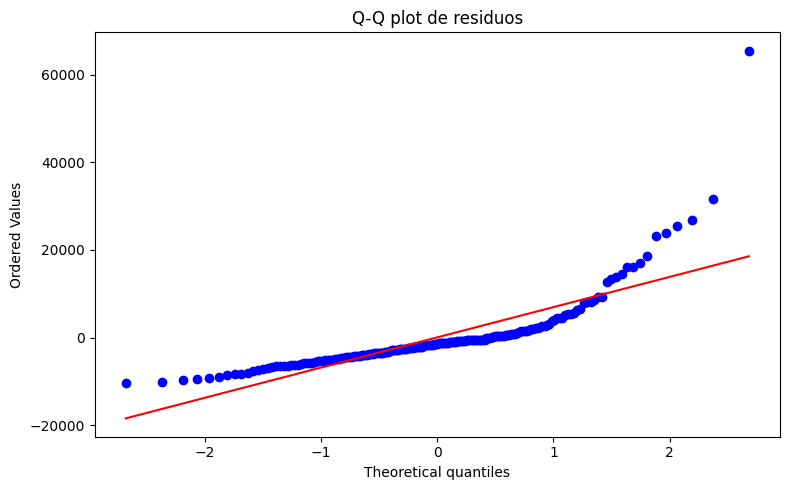

In [24]:
# Q-Q plot de residuos
plt.figure(figsize=(8, 5))
stats.probplot(residuos, dist='norm', plot=plt)
plt.title('Q-Q plot de residuos')
plt.tight_layout()
plt.savefig(FIGURES / 'qq_residuos.png', dpi=150)
plt.show()


En el Q-Q plot, los puntos deberian caer sobre la diagonal si los residuos fueran normales.
Los extremos suelen desviarse cuando hay valores atipicos.
